In [2]:

import os, time, math
from dataclasses import dataclass
from typing import List, Dict, Tuple, Set, Optional

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED
from rdkit import RDLogger

In [3]:

@dataclass
class VAEConfig:
    vocab_size: int
    emb_dim: int = 256
    enc_hidden: int = 512
    dec_hidden: int = 512
    num_layers: int = 1
    z_dim: int = 32
    dropout: float = 0.0

class SmilesVAE(nn.Module):
    def __init__(self, cfg: VAEConfig, pad_id: int, bos_id: int, eos_id: int):
        super().__init__()
        self.cfg = cfg
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id

        self.embed = nn.Embedding(cfg.vocab_size, cfg.emb_dim, padding_idx=pad_id)

        self.enc_gru = nn.GRU(cfg.emb_dim, cfg.enc_hidden, num_layers=cfg.num_layers,
                              batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0.0)
        self.to_mu = nn.Linear(cfg.enc_hidden, cfg.z_dim)
        self.to_logvar = nn.Linear(cfg.enc_hidden, cfg.z_dim)

        self.z_to_h0 = nn.Linear(cfg.z_dim, cfg.dec_hidden * cfg.num_layers)

        self.dec_gru = nn.GRU(cfg.emb_dim, cfg.dec_hidden, num_layers=cfg.num_layers,
                              batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0.0)
        self.fc_out = nn.Linear(cfg.dec_hidden, cfg.vocab_size)

    def encode(self, x):
        emb = self.embed(x)
        _, h = self.enc_gru(emb)
        h_last = h[-1]
        return self.to_mu(h_last), self.to_logvar(h_last)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_in = x[:, :-1]
        x_tgt = x[:, 1:]

        B = z.size(0)
        L = self.cfg.num_layers
        h0 = self.z_to_h0(z).view(L, B, self.cfg.dec_hidden).contiguous()

        emb = self.embed(x_in)
        out, _ = self.dec_gru(emb, h0)
        logits = self.fc_out(out)
        return logits, x_tgt, mu, logvar

def recon_loss(logits, targets, pad_id: int):
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(B*T, V), targets.reshape(B*T), ignore_index=pad_id)

In [5]:
import torch
import torch.nn.functional as F
from rdkit import Chem
from rdkit.Chem import Draw

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt = torch.load("./checkpoints_moses_full/freebits_fullmoses_z32_fn0.05.pt", map_location=device)

stoi = ckpt["stoi"]
itos = ckpt["itos"]
cfg_dict = ckpt["cfg"]
max_len = ckpt["max_len"]

pad_id = stoi["<PAD>"]
bos_id = stoi["<BOS>"]
eos_id = stoi["<EOS>"]

cfg = VAEConfig(**cfg_dict)

model = SmilesVAE(cfg, pad_id, bos_id, eos_id).to(device)
model.load_state_dict(ckpt["model_state"])
model.eval()

SmilesVAE(
  (embed): Embedding(29, 256, padding_idx=0)
  (enc_gru): GRU(256, 512, batch_first=True)
  (to_mu): Linear(in_features=512, out_features=32, bias=True)
  (to_logvar): Linear(in_features=512, out_features=32, bias=True)
  (z_to_h0): Linear(in_features=32, out_features=512, bias=True)
  (dec_gru): GRU(256, 512, batch_first=True)
  (fc_out): Linear(in_features=512, out_features=29, bias=True)
)

In [11]:
def generate_smiles(model, n=20):

    with torch.no_grad():

        z = torch.randn(n, model.cfg.z_dim).to(device)

        L = model.cfg.num_layers
        h = model.z_to_h0(z).view(L, n, model.cfg.dec_hidden)

        tokens = torch.full((n,1), bos_id).long().to(device)

        for _ in range(max_len):

            emb = model.embed(tokens[:, -1:])
            out, h = model.dec_gru(emb, h)

            logits = model.fc_out(out[:, -1])
            probs = torch.softmax(logits, dim=-1)

            next_tok = torch.multinomial(probs, 1)

            tokens = torch.cat([tokens, next_tok], dim=1)

        smiles = []

        for seq in tokens[:,1:]:
            chars = [itos[int(i)] for i in seq]

            s = "".join(chars)
            s = s.split("<EOS>")[0]
            s = s.replace("<PAD>", "")

            smiles.append(s)

        return smiles


smiles = generate_smiles(model, 20)
print(smiles)

['Cc1cccc(NC(=O)c2ccc(Br)c(O)c2)n1', 'Cc1ccc(CNC(=O)NC2CCN(c3ccc(F)cc3)C2=O)cc1', 'O=c1ccc2cc(C(F)(F)F)ccc2n1Cc1cnn(C)c1', 'CCC(C(=O)N1CCN(C(=O)Nc2cc(C)on2)CC1)c1ccccc1', 'CCN(Cc1ccccc1)C(=O)Cc1c(C)[nH]c(=O)[nH]c1=O', 'CC1CN(c2ccc(N)c(F)c2)CCN1Cc1nncn1C', 'Cc1c(CNC(=O)Nc2ccnc(C)n2)cnn1C', 'Cn1ccc(NS(=O)(=O)c2ccc3[nH]c(=O)c(=O)[nH]c3c2)n1', 'CSc1nccc(NCc2cccc(OCc3ccncc3)c2)n1', 'Cc1cc(NC(=O)c2cccs2)ccc1N1CCCCC1=O', 'COc1cccc(CC(=O)NCCc2nc(-c3cccnc3)n[nH]2)c1', 'CCc1noc(CC)c1CNC(=O)c1ccc2c(c1)OCCCO2', 'Cn1c(=O)oc2c(Oc3ccccc3)cc(OCC(N)=O)ccc21', 'O=C(NCc1ccc(O)cc1)NCC1CCOC1', 'CCN(CC)C(=O)CCNS(=O)(=O)c1ccc(F)c(C#N)c1', 'O=C(Cc1cccc(F)c1F)NCCc1ccc(S(N)(=O)=O)cc1', 'CC(=O)Nc1ccc(NC(=O)NCCC2=CCCCC2)cc1', 'CN(C(=O)CSc1nncn1C(C)C)C(C)c1ccco1', 'Cc1cc(-c2cnc3nc(C)n4c3C(=O)N2CCc2ccccc2)n(C)n1', 'COc1ccc(CNC(=O)c2nn(C)c(C)c2Br)cc1']


In [12]:
mols = []

for s in smiles:
    m = Chem.MolFromSmiles(s)
    if m:
        mols.append(m)

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(350,350)
)

Saved generated_molecules.png


[01:53:01] Can't kekulize mol.  Unkekulized atoms: 5 6 14 15 21 22 23
[01:53:01] SMILES Parse Error: unclosed ring for input: 'Cc1cc(-c2cnc3nc(C)n4c3C(=O)N2CCc2ccccc2)n(C)n1'


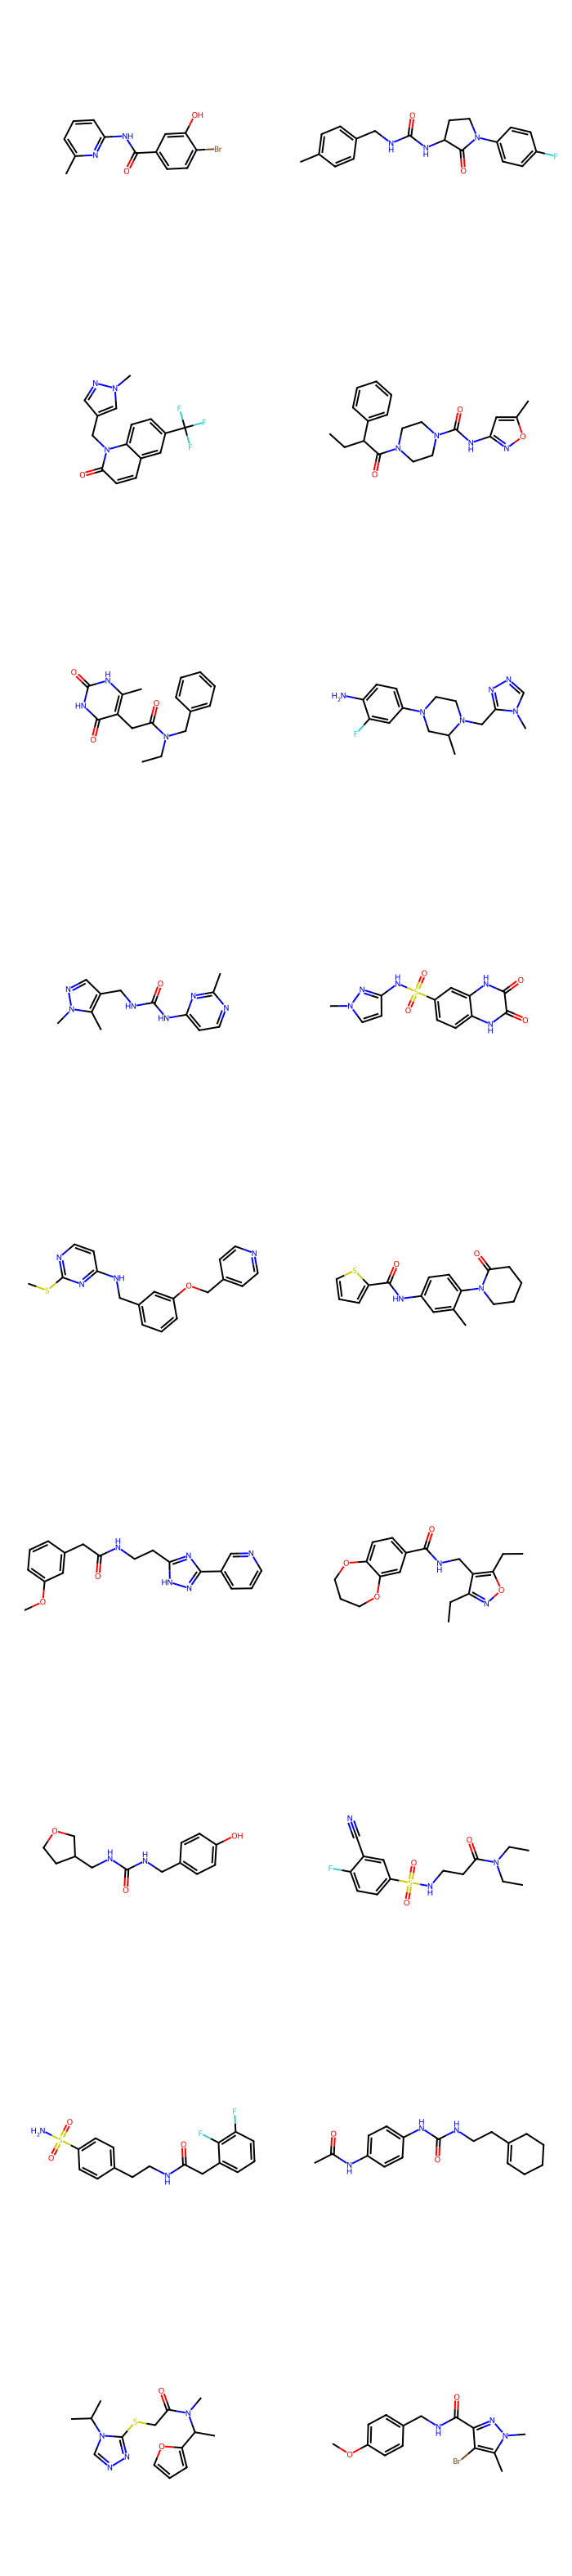

In [13]:
img